In [1]:
import pandas as pd

In [2]:
id = '1PAvCQL5tjyZfwGCg72OPFRYLl7hjpDtK'
url = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(url)
df.head()

,role,skills,description
0,data analyst,"problem solving, data analysis, predictive ana...",NaN
1,data analyst,"sql, database administration, advanced statist...",NaN
2,data analyst,"data analysis, data visualization, statistical...",NaN
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN
4,data analyst,"variable cost productivity, data analytics, co...",NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26066 entries, 0 to 26065
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   role         26066 non-null  object
 1   skills       25769 non-null  object
 2   description  5901 non-null   object
dtypes: object(3)
memory usage: 611.0+ KB


In [4]:
df_final = df.dropna(subset=['skills']).copy()
df_final.drop_duplicates(inplace=True)
df_final

,role,skills,description
0,data analyst,"problem solving, data analysis, predictive ana...",NaN
1,data analyst,"sql, database administration, advanced statist...",NaN
2,data analyst,"data analysis, data visualization, statistical...",NaN
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN
4,data analyst,"variable cost productivity, data analytics, co...",NaN
...,...,...,...
26061,data analyst,"c, go, sql",company description it all started with an ide...
26062,data analyst,"excel, sql","our client, a leader in the data industry, is ..."
26063,data analyst,"github, qlik, tableau, power_bi, bitbucket, r,...","tickets for less®, a leading live entertainmen..."
26064,data analyst,"t-sql, power_bi, tableau, sharepoint, excel, g...",job description provides programs to improve o...


In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25716 entries, 0 to 26065
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   role         25716 non-null  object
 1   skills       25716 non-null  object
 2   description  5556 non-null   object
dtypes: object(3)
memory usage: 803.6+ KB


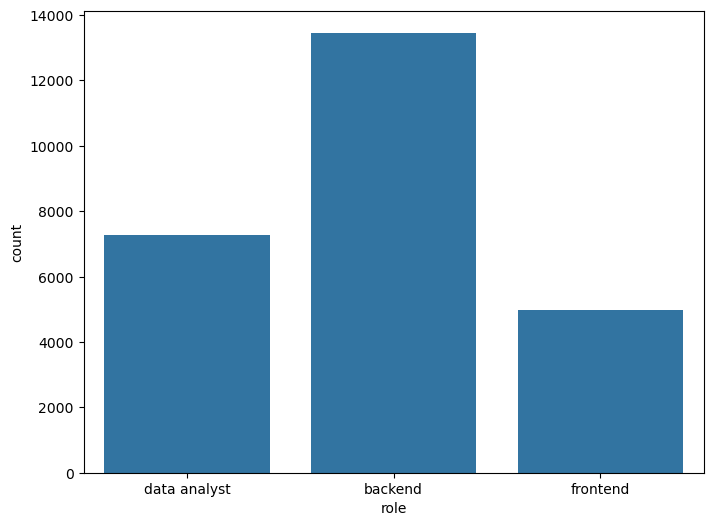

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(data=df_final, x='role')
plt.show()

In [7]:
COMBINED_SKILLS = {
    "html css": ["html", "css"],
}

def clean_skill_function(x):
    split_skills = [i.strip().lower() for i in x.split(',')]
    
    final_skills = []
    for skill in split_skills:
        if skill in COMBINED_SKILLS:
            final_skills.extend(COMBINED_SKILLS[skill])  # pecah jadi beberapa
        else:
            final_skills.append(skill)
    
    return final_skills


df_final['clean_skills'] = df_final['skills'].apply(clean_skill_function)

In [8]:
skill_alias = {
    "py": "python",
    "python3": "python",
    "python 3": "python",
    "django rest": "django_rest_framework",
    "django rest framework": "django_rest_framework",
    "drf": "django_rest_framework",
    "flask api": "flask",
    "fast api": "fastapi",
    "fast-api": "fastapi",
    "nodejs": "node.js",
    "node js": "node.js",
    "node-js": "node.js",
    "reactjs": "react",
    "react js": "react",
    "nextjs": "next.js",
    "next js": "next.js",
    "vuejs": "vue",
    "vue js": "vue",
    "angularjs": "angular",
    "angular js": "angular",
    "js": "javascript",
    "ts": "typescript",
    "postgres": "postgresql",
    "postgre": "postgresql",
    "psql": "postgresql",
    "postgre_sql": "postgresql",
    "postgre-sql": "postgresql",
    "postgre sql": "postgresql",
    "my sql": "mysql",
    "my_sql": "mysql",
    "my-sql": "mysql",
    "mongo": "mongodb",
    "mongo_db": "mongodb",
    "mongo-db": "mongodb",
    "mongo db": "mongodb",
    "ms sql": "sql_server",
    "mssql": "sql_server",
    "sql server": "sql_server",
    "t sql": "t-sql",
    "power bi": "power_bi",
    "power-bi": "power_bi",
    "powerbi": "power_bi",
    "ms excel": "excel",
    "advanced excel": "excel",
    "google sheet": "google_sheets",
    "google sheets": "google_sheets",
    "machine learning": "machine_learning",
    "ml": "machine_learning",
    "data analysis": "data_analysis",
    "data analytics": "data_analysis",
    "data visualization": "data_visualization",
    "data viz": "data_visualization",
    "statistical analysis": "statistics",
    "stats": "statistics",
    "business_process_analysis": "business_analysis",
    "business process analysis": "business_analysis",
    "aws cloud": "aws",
    "amazon web services": "aws",
    "gcp": "google_cloud",
    "google cloud platform": "google_cloud",
    "azure cloud": "azure",
    "docker container": "docker",
    "k8s": "kubernetes",
    "gitlab": "git",
    "github": "git",
    "bitbucket": "git",
    "c sharp": "c#",
    "c-sharp": "c#",
    "dotnet": ".net",
    "asp net": "asp.net",
    "asp.net core": "asp.net",
    "bash shell": "bash",
    "bash shell all shells": "bash",
    "bash shell  all shells": "bash",
    "all shells": "bash",
    "maven build tool": "maven",
    "ms sql server": "mysql",
    "databases": "database"
}


In [9]:
def normalize_skill_list(skill_list):
    return [skill_alias.get(s, s) for s in skill_list]

df_final["clean_skills"] = df_final["clean_skills"].apply(normalize_skill_list)
df_final

,role,skills,description,clean_skills
0,data analyst,"problem solving, data analysis, predictive ana...",NaN,"[problem solving, data_analysis, predictive an..."
1,data analyst,"sql, database administration, advanced statist...",NaN,"[sql, database administration, advanced statis..."
2,data analyst,"data analysis, data visualization, statistical...",NaN,"[data_analysis, data_visualization, statistica..."
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN,"[revenue cycle, healthcare data analysis, data..."
4,data analyst,"variable cost productivity, data analytics, co...",NaN,"[variable cost productivity, data_analysis, co..."
...,...,...,...,...
26061,data analyst,"c, go, sql",company description it all started with an ide...,"[c, go, sql]"
26062,data analyst,"excel, sql","our client, a leader in the data industry, is ...","[excel, sql]"
26063,data analyst,"github, qlik, tableau, power_bi, bitbucket, r,...","tickets for less®, a leading live entertainmen...","[git, qlik, tableau, power_bi, git, r, aws, py..."
26064,data analyst,"t-sql, power_bi, tableau, sharepoint, excel, g...",job description provides programs to improve o...,"[t-sql, power_bi, tableau, sharepoint, excel, ..."


In [10]:
df_final["clean_skills"] = df_final["clean_skills"].apply(lambda x: sorted(set(x)))
df_final

,role,skills,description,clean_skills
0,data analyst,"problem solving, data analysis, predictive ana...",NaN,"[bachelor's degree, business_analysis, collabo..."
1,data analyst,"sql, database administration, advanced statist...",NaN,"[acd, advanced statistical analysis, bachelor'..."
2,data analyst,"data analysis, data visualization, statistical...",NaN,"[a b testing, business intelligence, data mana..."
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN,"[2+ years of data analysis in healthcare, 4+ y..."
4,data analyst,"variable cost productivity, data analytics, co...",NaN,"[c++, cfda, costbenefit analysis, css, data mi..."
...,...,...,...,...
26061,data analyst,"c, go, sql",company description it all started with an ide...,"[c, go, sql]"
26062,data analyst,"excel, sql","our client, a leader in the data industry, is ...","[excel, sql]"
26063,data analyst,"github, qlik, tableau, power_bi, bitbucket, r,...","tickets for less®, a leading live entertainmen...","[aws, azure, git, power_bi, python, qlik, r, s..."
26064,data analyst,"t-sql, power_bi, tableau, sharepoint, excel, g...",job description provides programs to improve o...,"[excel, go, power_bi, sharepoint, spreadsheet,..."


In [11]:
df_final = df_final[df_final["clean_skills"].map(len) > 0]
df_final.head()

,role,skills,description,clean_skills
0,data analyst,"problem solving, data analysis, predictive ana...",NaN,"[bachelor's degree, business_analysis, collabo..."
1,data analyst,"sql, database administration, advanced statist...",NaN,"[acd, advanced statistical analysis, bachelor'..."
2,data analyst,"data analysis, data visualization, statistical...",NaN,"[a b testing, business intelligence, data mana..."
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN,"[2+ years of data analysis in healthcare, 4+ y..."
4,data analyst,"variable cost productivity, data analytics, co...",NaN,"[c++, cfda, costbenefit analysis, css, data mi..."


In [12]:
import re

BLACKLIST_PATTERNS = [
    r"\byears?\b",
    r"\bdegree\b",
    r"\bbachelor\b",
    r"\bmaster\b",
    r"\bphd\b",
    r"\bexperience\b",
    'acd'
]

def remove_noise(skills):
    clean = []
    for s in skills:
        if not any(re.search(p, s) for p in BLACKLIST_PATTERNS):
            clean.append(s)
    return clean
df_final['clean_skills'] = df_final['clean_skills'].apply(remove_noise)
df_final

,role,skills,description,clean_skills
0,data analyst,"problem solving, data analysis, predictive ana...",NaN,"[business_analysis, collaboration, communicati..."
1,data analyst,"sql, database administration, advanced statist...",NaN,"[advanced statistical analysis, backoffice wor..."
2,data analyst,"data analysis, data visualization, statistical...",NaN,"[a b testing, business intelligence, data mana..."
3,data analyst,"revenue cycle, healthcare data analysis, data ...",NaN,"[agile development, analytic methods, certifie..."
4,data analyst,"variable cost productivity, data analytics, co...",NaN,"[c++, cfda, costbenefit analysis, css, data mi..."
...,...,...,...,...
26061,data analyst,"c, go, sql",company description it all started with an ide...,"[c, go, sql]"
26062,data analyst,"excel, sql","our client, a leader in the data industry, is ...","[excel, sql]"
26063,data analyst,"github, qlik, tableau, power_bi, bitbucket, r,...","tickets for less®, a leading live entertainmen...","[aws, azure, git, power_bi, python, qlik, r, s..."
26064,data analyst,"t-sql, power_bi, tableau, sharepoint, excel, g...",job description provides programs to improve o...,"[excel, go, power_bi, sharepoint, spreadsheet,..."


In [13]:
from collections import Counter
from itertools import chain
all_skills_flat = list(chain.from_iterable(df_final["clean_skills"]))
Counter(all_skills_flat).most_common(30)

[('sql', 13524),
 ('javascript', 11584),
 ('docker', 10465),
 ('python', 10135),
 ('html', 8629),
 ('css', 8588),
 ('npm', 8581),
 ('typescript', 7583),
 ('react', 6455),
 ('java', 6059),
 ('node.js', 6012),
 ('bash', 5392),
 ('kubernetes', 4632),
 ('homebrew', 4340),
 ('yarn', 4325),
 ('c#', 4083),
 ('pip', 3887),
 ('webpack', 3854),
 ('go', 3346),
 ('maven  build tool', 3304),
 ('make', 3138),
 ('angular', 3098),
 ('php', 3082),
 ('.net  5+', 2996),
 ('jquery', 2865),
 ('tableau', 2824),
 ('spring boot', 2753),
 ('asp.net', 2728),
 ('gradle', 2687),
 ('excel', 2674)]

In [14]:
all_skills = sorted(set(chain.from_iterable(df_final["clean_skills"])))

In [15]:
role_skill_freq = (
    df_final.explode("clean_skills")
      .groupby(["role", "clean_skills"])
      .size()
      .reset_index(name="count")
)
role_skill_freq.sort_values(by='count', ascending=False).head(30)

,role,clean_skills,count
124,backend,docker,8572
362,backend,sql,7212
200,backend,javascript,6874
304,backend,python,6054
263,backend,npm,5112
9555,data analyst,sql,5076
199,backend,java,5028
89,backend,css,4675
186,backend,html,4675
36,backend,bash,4500


In [16]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

/home/alvin/anaconda3/envs/torch_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
skill_embeddings = model.encode(
    all_skills,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches: 100%|███████████████████████████████| 343/343 [00:02<00:00, 170.84it/s]


In [18]:
# import numpy as np

# np.save("skill_embeddings.npy", skill_embeddings)

In [19]:
import pickle

with open("skill_vocab.pkl", "wb") as f:
    pickle.dump(all_skills, f)

In [20]:
role_skill_freq["importance"] = (
    role_skill_freq.groupby("role")["count"]
    .transform(lambda x: x / x.max())
)

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

class Inference():
    model = None
    role_skill_freq = None
    skill_embeddings = None
    all_skills = None
    
    def __init__(self, target_role, user_skills, top_k=10):
        self.target_role = target_role
        self.user_skills = user_skills
        self.top_k = top_k
    
    def filter_role(self):
        self.role_df = self.role_skill_freq[self.role_skill_freq["role"] == self.target_role].copy()
        return self.role_df
    
    def encode_user_skills(self):
        self.user_emb = self.model.encode(self.user_skills, normalize_embeddings=True)
        return self.user_emb
    
    def similarity(self):
        sim_matrix = cosine_similarity(self.user_emb, self.skill_embeddings)
        skill_sim_scores = sim_matrix.max(axis=0)
        skill_sim_map = dict(zip(self.all_skills, skill_sim_scores))
        
        self.role_df["similarity"] = (self.role_df["clean_skills"]
                                     .map(skill_sim_map)
                                     .fillna(0))
        return self.role_df
    
    def importance(self):
        self.role_df["importance"] = (self.role_df.groupby("role")["count"]
                                      .transform(lambda x: x / x.max())
                                     )
        return self.role_df
    
    def mark_user_skills(self):
        user_skills_set = set(self.user_skills)
        self.role_df["has_skill"] = self.role_df["clean_skills"].isin(user_skills_set)
        return self.role_df
    
    def final_score(self):
        w_sim = 0.8
        w_imp = 0.2
        
        self.role_df["final_score"] = (
            w_sim * self.role_df["similarity"] + 
            w_imp * self.role_df["importance"]
        )
        return self.role_df
    
    def recomendations(self):
        self.recomendations_df = (
            self.role_df[~self.role_df["has_skill"]]
            .sort_values("final_score", ascending=False)
            .head(self.top_k)
            .reset_index(drop=True)
        )
        return self.recomendations_df
    
    def result(self):
        for _, row in self.recomendations_df.iterrows():
            skill = row["clean_skills"]
            pct = round(row["final_score"] * 100)    # tingkat kecocokan
            print(f"{skill} -> {pct}%")
    
    def show_output(self):
        self.filter_role()
        self.encode_user_skills()
        self.similarity()
        self.importance()
        self.mark_user_skills()
        self.final_score()
        self.recomendations()
        return self.result()

In [26]:
role = "backend"
skill = ["python", "sql"]

In [27]:
Inference.model = model
Inference.role_skill_freq = role_skill_freq
Inference.skill_embeddings = skill_embeddings
Inference.all_skills = all_skills

In [28]:
inf = Inference(role, skill)
inf.show_output()    # skill -> tingkat kecocokan

database -> 56%
mysql -> 55%
pip -> 53%
relational databases -> 50%
numpy -> 48%
java -> 48%
django -> 43%
flask -> 41%
javascript -> 41%
bash -> 41%
